# Paper Figures — Delta-V Perturbation Potential

In [54]:
import os, sys
VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
if VENV_PATH not in sys.path:
    sys.path.append(VENV_PATH)

_cwd = os.path.abspath('')
PROJECT_ROOT = _cwd
for _ in range(5):
    if os.path.isdir(os.path.join(PROJECT_ROOT, 'examples')):
        break
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
np.Inf = np.inf

import torch
from torch.nn import functional as F
# PyTorch 2.6+ compat: force weights_only=False (safe to re-run)
if not getattr(torch, '_load_patched', False):
    _orig_torch_load = torch.load
    def _patched_torch_load(*args, **kwargs):
        kwargs.setdefault('weights_only', False)
        return _orig_torch_load(*args, **kwargs)
    torch.load = _patched_torch_load
    torch._load_patched = True

import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import minimize
from pytorch_lightning import seed_everything
from examples.pend_lag_cavae_trainer import Model
from examples.pend_delta_v_frozen_trainer import DeltaVFrozenModel
from examples.pend_delta_v_lora_trainer import DeltaVLoRAModel
from lag_caVAE.lag_lora_v import LoRALinear

seed_everything(0)
%matplotlib inline

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

SAVE_DIR = os.path.join(PROJECT_ROOT, 'results', 'pend', 'paper_figures')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Figures will be saved to: {SAVE_DIR}')

Figures will be saved to: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/results/pend/paper_figures


In [55]:
# ── Checkpoints ──
CKPT_UNPERTURBED = 'pend-lag-cavae-T_p=4-epoch=983-step=7871.ckpt'
CKPT_DELTA_V     = 'poly_cubic_0_1125_lora8.ckpt'

# ── Perturbation ground truth ──
ETA3 = 0.1125
ALPHA3 = 3 * ETA3  # = 0.675

true_da     = lambda theta, M: -ALPHA3 * theta**3
true_dV_raw = lambda theta, M: M * (ALPHA3 / 4) * theta**4

# ── Sampling ──
N_SAMPLES = 500
THETA_MIN, THETA_MAX = 0, 2 * np.pi

print(f'Perturbation: pure cubic, eta3 = {ETA3}')
print(f'  True da = -{ALPHA3} * theta^3')
print(f'  True dV = M * {ALPHA3}/4 * theta^4')

Perturbation: pure cubic, eta3 = 0.1125
  True da = -0.3375 * theta^3
  True dV = M * 0.3375/4 * theta^4


In [56]:
# ── Helper functions (identical to 8_deltaV_retrain.ipynb) ──

def extract_physics(model, theta_np):
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    V = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    dV_dtheta = torch.autograd.grad(V.sum(), theta, create_graph=False)[0]
    M_flat = M.squeeze()
    acc = -(1.0 / M_flat) * dV_dtheta
    return {
        'theta': theta_np,
        'V':         V.detach().numpy().flatten(),
        'M':         M.detach().numpy().flatten(),
        'dVdtheta':  dV_dtheta.detach().numpy().flatten(),
        'acc':       acc.detach().numpy().flatten(),
    }

def extract_delta_v_physics(model, theta_np):
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    delta_V = model.ode.delta_V_net(cos_sin)
    V_base = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    M_flat = M.squeeze()
    V_total = V_base + delta_V
    dV_total_dtheta = torch.autograd.grad(
        V_total.sum(), theta, retain_graph=True, create_graph=False)[0]
    d_delta_V_dtheta = torch.autograd.grad(
        delta_V.sum(), theta, create_graph=False)[0]
    delta_acc = -(1.0 / M_flat) * d_delta_V_dtheta
    total_acc = -(1.0 / M_flat) * dV_total_dtheta
    return {
        'theta':          theta_np,
        'delta_V':        delta_V.detach().numpy().flatten(),
        'd_delta_V':      d_delta_V_dtheta.detach().numpy().flatten(),
        'delta_acc':      delta_acc.detach().numpy().flatten(),
        'V_base':         V_base.detach().numpy().flatten(),
        'V_total':        V_total.detach().numpy().flatten(),
        'total_acc':      total_acc.detach().numpy().flatten(),
        'M':              M_flat.detach().numpy().flatten(),
    }

def extract_delta_v_physics_lora(model, theta_np):
    """Extract LoRA-induced perturbation by comparing V_net with/without LoRA."""
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)

    M = model.ode.M_net(cos_sin)
    M_flat = M.squeeze()

    # V_total: V_net with LoRA enabled (normal forward pass)
    V_total = model.ode.V_net(cos_sin)
    dV_total_dtheta = torch.autograd.grad(
        V_total.sum(), theta, retain_graph=True, create_graph=False)[0]

    # V_base: temporarily disable LoRA by zeroing scaling
    saved_scalings = {}
    for name, module in model.ode.V_net.named_modules():
        if isinstance(module, LoRALinear):
            saved_scalings[name] = module.scaling
            module.scaling = 0.0

    theta2 = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q2 = torch.cos(theta2)
    sin_q2 = torch.sin(theta2)
    cos_sin2 = torch.stack((cos_q2, sin_q2), dim=1)
    V_base = model.ode.V_net(cos_sin2)

    # Restore LoRA scaling
    for name, module in model.ode.V_net.named_modules():
        if isinstance(module, LoRALinear):
            module.scaling = saved_scalings[name]

    delta_V = V_total.detach() - V_base.detach()

    dV_base_dtheta = torch.autograd.grad(
        V_base.sum(), theta2, create_graph=False)[0]
    d_delta_V_dtheta = dV_total_dtheta.detach() - dV_base_dtheta.detach()

    total_acc = -(1.0 / M_flat.detach()) * dV_total_dtheta.detach()
    delta_acc = -(1.0 / M_flat.detach()) * d_delta_V_dtheta

    return {
        'theta':          theta_np,
        'delta_V':        delta_V.numpy().flatten(),
        'd_delta_V':      d_delta_V_dtheta.numpy().flatten(),
        'delta_acc':      delta_acc.numpy().flatten(),
        'V_base':         V_base.detach().numpy().flatten(),
        'V_total':        V_total.detach().numpy().flatten(),
        'total_acc':      total_acc.numpy().flatten(),
        'M':              M_flat.detach().numpy().flatten(),
    }

def calibrate_phase_offset(phi, a_unpert, g=10.0, l=1.0):
    K = 3 * g / (2 * l)
    best = None
    for s in [1.0, -1.0]:
        for off0 in np.linspace(0, 2*np.pi, 40):
            res = minimize(
                lambda o: np.mean((a_unpert - (-K * np.sin(s * (phi + o[0]))))**2),
                [off0], method='Nelder-Mead')
            if best is None or res.fun < best[0]:
                best = (res.fun, s, res.x[0])
    mse, sign, offset = best
    res_free = minimize(
        lambda p: np.mean((a_unpert - (p[0] * np.sin(sign * (phi + offset))))**2),
        [-K], method='Nelder-Mead')
    amp_fitted = res_free.x[0]
    return {
        'offset': offset, 'sign': sign, 'amplitude': amp_fitted,
        'mse': mse, 'expected_amplitude': -K,
    }

def phi_to_theta_phys(phi, calib):
    theta = calib['sign'] * (phi + calib['offset'])
    return ((theta + np.pi) % (2 * np.pi)) - np.pi

print('Helper functions defined.')

Helper functions defined.


In [57]:
# ── Load models ──
ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')

model_unpert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_UNPERTURBED), map_location='cpu')
model_unpert.eval()

# Detect model type from checkpoint hyperparameters
ckpt_path_poly = os.path.join(ckpt_dir, CKPT_DELTA_V)
ckpt_data = torch.load(ckpt_path_poly, map_location='cpu')
hp = ckpt_data.get('hyper_parameters', {})
is_lora = 'lora_rank' in hp
has_latent = 'latent_alpha' in hp
del ckpt_data

if is_lora:
    from examples.pend_delta_v_lora_trainer import DeltaVLoRAModel
    model_delta_v = DeltaVLoRAModel.load_from_checkpoint(ckpt_path_poly, map_location='cpu')
    print(f"Loaded as DeltaVLoRAModel (LoRA rank={hp.get('lora_rank')})")
    USE_LORA = True
else:
    model_delta_v = DeltaVFrozenModel.load_from_checkpoint(ckpt_path_poly, map_location='cpu')
    print("Loaded as DeltaVFrozenModel")
    USE_LORA = False
model_delta_v.eval()

# ── Extract & calibrate ──
theta_range = np.linspace(THETA_MIN, THETA_MAX, N_SAMPLES)

phys_unpert = extract_physics(model_unpert, theta_range)

calib = calibrate_phase_offset(theta_range, phys_unpert['acc'])
print(f"Phase calibration: sign={calib['sign']:+.0f}, offset={calib['offset']:.4f} rad")
print(f"  amplitude (fitted) = {calib['amplitude']:.2f}, expected = {calib['expected_amplitude']:.2f}")

theta_phys = phi_to_theta_phys(theta_range, calib)
sort_idx = np.argsort(theta_phys)
theta_gt = theta_phys[sort_idx]

if USE_LORA:
    delta_v_phys = extract_delta_v_physics_lora(model_delta_v, theta_range)
else:
    delta_v_phys = extract_delta_v_physics(model_delta_v, theta_range)

# Sort everything to physical coordinates
delta_V_sorted     = delta_v_phys['delta_V'][sort_idx]
delta_V_sorted     = delta_V_sorted - delta_V_sorted[0]  # zero-anchor
delta_acc_sorted   = delta_v_phys['delta_acc'][sort_idx]
V_base_sorted      = delta_v_phys['V_base'][sort_idx]
V_total_sorted     = delta_v_phys['V_total'][sort_idx]
total_acc_sorted   = delta_v_phys['total_acc'][sort_idx]
M_sorted           = delta_v_phys['M'][sort_idx]
a_unpert_sorted    = phys_unpert['acc'][sort_idx]
V_unpert_sorted    = phys_unpert['V'].flatten()[sort_idx]

M_scale = np.mean(M_sorted)
K_fitted = abs(calib['amplitude'])

# Ground truth
true_delta_a     = true_da(theta_gt, M_scale)
true_delta_V_raw = true_dV_raw(theta_gt, M_scale)
true_delta_V     = true_delta_V_raw - true_delta_V_raw[0]  # zero-anchor

V_true_unpert = -M_scale * K_fitted * np.cos(theta_gt)
V_true_unpert += np.mean(V_unpert_sorted) - np.mean(V_true_unpert)

V_true_pert = V_true_unpert + true_delta_V_raw

# R2 scores
r2_dV = r2_score(true_delta_V, delta_V_sorted)
r2_da = r2_score(true_delta_a, delta_acc_sorted)

print(f'\nM_scale = {M_scale:.4f}, K_fitted = {K_fitted:.4f}')
print(f'R2(dV) = {r2_dV:.4f}, R2(da) = {r2_da:.4f}')
print('Data ready.')

Loaded as DeltaVLoRAModel (LoRA rank=8)
Phase calibration: sign=+1, offset=2.2050 rad
  amplitude (fitted) = -15.45, expected = -15.00

M_scale = 0.6915, K_fitted = 15.4497
R2(dV) = 0.7899, R2(da) = 0.8134
Data ready.


In [58]:
# ── Publication plot style ──
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'legend.framealpha': 1.0,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'lines.linewidth': 1.8,
})

# Shared x-axis formatting
PI_TICKS = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
PI_LABELS = [r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']

# Colors
C_LEARNED = '#0072B2'   # blue (colorblind safe)
C_TRUE    = '#D55E00'   # vermillion (colorblind safe)
C_PERT    = '#CC79A7'   # reddish-purple

# Journal single column width ~3.5in, double ~7in
FIG_W = 4.5   # single column with margins
FIG_H = 3.2

print('Plot style set.')

Plot style set.


## Figure 1 — Unperturbed Potential Energy

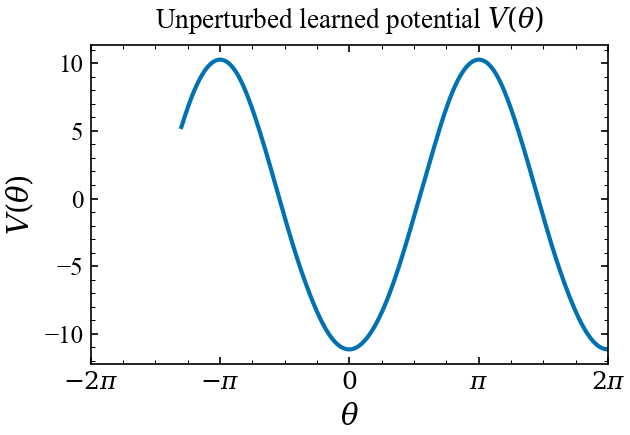

In [59]:
# ── Extended range data ──
phi_ext = np.linspace(-2*np.pi, 2*np.pi, 1000)
phys_u_ext = extract_physics(model_unpert, phi_ext)
if USE_LORA:
    dv_ext = extract_delta_v_physics_lora(model_delta_v, phi_ext)
else:
    dv_ext = extract_delta_v_physics(model_delta_v, phi_ext)

theta_ext = calib['sign'] * (phi_ext + calib['offset'])
theta_center = calib['sign'] * calib['offset']
theta_ext = theta_ext - np.round(theta_center / (2*np.pi)) * 2*np.pi
sort_ext = np.argsort(theta_ext)
theta_ext_sorted = theta_ext[sort_ext]

V_unpert_ext = phys_u_ext['V'].flatten()[sort_ext]
V_total_ext = dv_ext['V_total'][sort_ext]

K_fitted_ext = abs(calib['amplitude'])
V_true_unpert_ext = -M_scale * K_fitted_ext * np.cos(theta_ext_sorted)
V_true_unpert_ext += np.mean(V_unpert_ext) - np.mean(V_true_unpert_ext)

PI2_TICKS = [-2*np.pi, -np.pi, 0, np.pi, 2*np.pi]
PI2_LABELS = [r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$', r'$2\pi$']

# ── Figure 1: Unperturbed potential ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_ext_sorted, V_unpert_ext, color=C_LEARNED, lw=2.0, label='Learned')

ax.set_title(r'Unperturbed learned potential $V(\theta)$', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$V(\theta)$')
ax.set_xlim(-2*np.pi, 2*np.pi)
ax.set_xticks(PI2_TICKS)
ax.set_xticklabels(PI2_LABELS)
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_unperturbed.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_unperturbed.png'))
plt.show()

## Figure 1b — Unperturbed Potential with Reconstructed Images

Dataset loaded: X shape = torch.Size([20, 256, 32, 32])
  Target θ=-2.30, found θ=-2.31
  Target θ=-0.90, found θ=-0.89
  Target θ=0.30, found θ=0.30
  Target θ=1.40, found θ=1.40
  Target θ=2.60, found θ=2.59


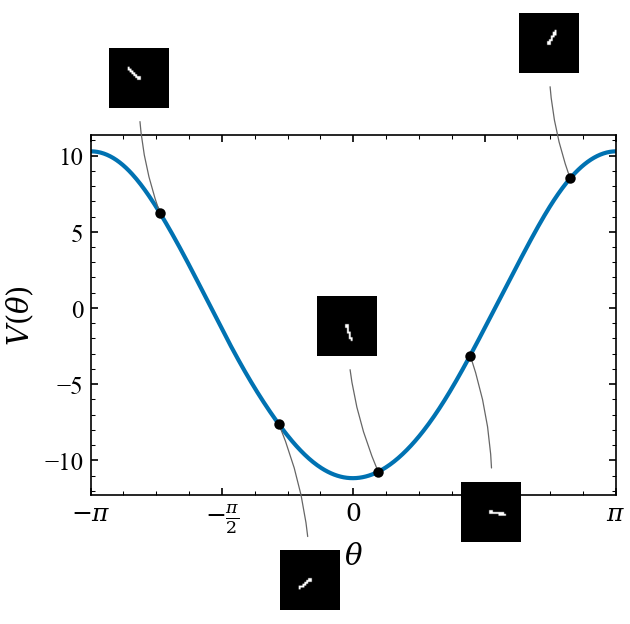

In [60]:
# ── Figure 1b: V(θ) with REAL dataset images at marked positions ──
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from utils import ImageDataset, my_collate
from torch.utils.data import DataLoader

# Load unperturbed dataset (real images)
data_path = os.path.join(PROJECT_ROOT, 'datasets',
                         'pendulum-gym-image-dataset-test-reverse-angle-stable-down-2.pkl')
test_dataset = ImageDataset(data_path, 19, ctrl=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, collate_fn=my_collate)
X_all, u_all = next(iter(test_loader))  # X: [T, bs, 32, 32]
print(f'Dataset loaded: X shape = {X_all.shape}')

# Encode all frames to get their physical θ
n_trajs = min(X_all.shape[1], 100)
all_images = []
all_phi = []

with torch.no_grad():
    for t_idx in range(X_all.shape[0]):
        for b_idx in range(n_trajs):
            img = X_all[t_idx, b_idx]  # [32, 32]
            img_flat = img.reshape(1, 32*32)
            q_m_logv = model_unpert.recog_q_net(img_flat)
            q_m, _ = q_m_logv.split([2, 1], dim=1)
            q_m_n = q_m / q_m.norm(dim=-1, keepdim=True)
            phi = torch.atan2(q_m_n[0, 1], q_m_n[0, 0]).item()
            all_images.append(img.numpy())
            all_phi.append(phi)

all_phi = np.array(all_phi)
all_theta_phys = phi_to_theta_phys(all_phi, calib)

# 5 non-symmetrical angles spanning the potential curve
target_thetas = np.array([-2.3, -0.9, 0.3, 1.4, 2.6])
selected_imgs = []
selected_thetas_actual = []

for t_target in target_thetas:
    idx = np.argmin(np.abs(all_theta_phys - t_target))
    selected_imgs.append(all_images[idx])
    selected_thetas_actual.append(all_theta_phys[idx])
    print(f'  Target θ={t_target:.2f}, found θ={all_theta_phys[idx]:.2f}')

selected_thetas_actual = np.array(selected_thetas_actual)

# Interpolate V values from the extended-range data computed in cell 7
marker_V = np.interp(selected_thetas_actual, theta_ext_sorted, V_unpert_ext)

# Restrict existing V curve to [-π, π] for a tighter plot
mask_pi = (theta_ext_sorted >= -np.pi) & (theta_ext_sorted <= np.pi)
theta_plot = theta_ext_sorted[mask_pi]
V_plot = V_unpert_ext[mask_pi]

# ── Plot ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1.0))

ax.plot(theta_plot, V_plot, color=C_LEARNED, lw=2.0)
ax.plot(selected_thetas_actual, marker_V, 'o', color='black',
        markersize=4, zorder=5, clip_on=False)

ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$V(\theta)$')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(PI_TICKS)
ax.set_xticklabels(PI_LABELS)
ax.minorticks_on()

# Image annotations: alternate above/below, slight horizontal offsets
offsets_xy = [
    (-10, 65),   # -2.3: above, slight left
    (15, -75),   # -0.9: below, slight right
    (-15, 70),   # 0.3: above, slight left
    (10, -75),   # 1.4: below, slight right
    (-10, 65),   # 2.6: above, slight left
]

for i in range(len(selected_imgs)):
    imagebox = OffsetImage(selected_imgs[i], zoom=0.9, cmap='gray')
    ab = AnnotationBbox(imagebox, (selected_thetas_actual[i], marker_V[i]),
                        xybox=offsets_xy[i],
                        boxcoords="offset points",
                        arrowprops=dict(arrowstyle="-", color='0.4',
                                        lw=0.6, connectionstyle="arc3,rad=0.1"),
                        frameon=False)
    ax.add_artist(ab)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_unperturbed_with_images.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_unperturbed_with_images.png'))
plt.show()


## Figure 2 — Learned Perturbation Potential $\Delta V$

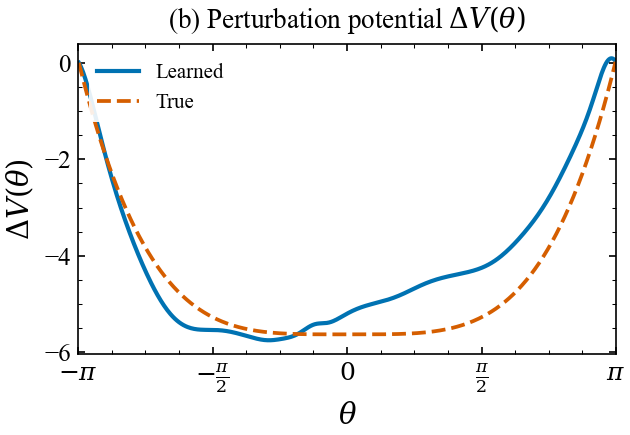

In [61]:
# ── Figure 2: Perturbation potential ΔV on [-π, π] ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_gt, delta_V_sorted, color=C_LEARNED, lw=2.0, label='Learned')
ax.plot(theta_gt, true_delta_V, color=C_TRUE, lw=1.8, ls='--', label='True')

ax.set_title(r'(b) Perturbation potential $\Delta V(\theta)$', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\Delta V(\theta)$')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(PI_TICKS)
ax.set_xticklabels(PI_LABELS)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_learned.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_learned.png'))
plt.show()

## Figure 3 — Perturbed Potential Energy

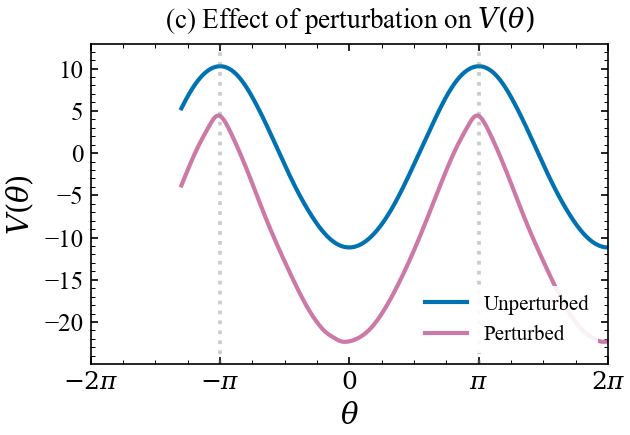

In [62]:
# ── Figure 3: Perturbed vs unperturbed potential ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_ext_sorted, V_unpert_ext, color=C_LEARNED, lw=2.0, label='Unperturbed')
ax.plot(theta_ext_sorted, V_total_ext, color=C_PERT, lw=2.0, label='Perturbed')

ax.set_title(r'(c) Effect of perturbation on $V(\theta)$', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$V(\theta)$')
ax.set_xlim(-2*np.pi, 2*np.pi)
ax.set_xticks(PI2_TICKS)
ax.set_xticklabels(PI2_LABELS)

# Set y-limits to cover full data range with padding
y_min = min(V_unpert_ext.min(), V_total_ext.min())
y_max = max(V_unpert_ext.max(), V_total_ext.max())
y_pad = (y_max - y_min) * 0.08
ax.set_ylim(y_min - y_pad, y_max + y_pad)
ax.yaxis.set_major_locator(plt.MultipleLocator(5))

ax.axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
ax.axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_perturbed.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_perturbed.png'))
plt.show()

---
# Delta-V Net (Additive) Perturbation Plots

These plots use the **delta_V_net** approach: a separate small MLP adds $\Delta V$ to the frozen $V_\text{net}$.
Checkpoints are `DeltaVFrozenModel` trained with `pend_delta_v_frozen_trainer.py`.

In [63]:
# ── Delta-V net polynomial config ──
CKPT_DVN_POLY = 'poly-cubic-original.ckpt'

# Same perturbation as LoRA poly section: eta3=0.1125, alpha3=0.3375
DVN_ETA3 = 0.1125
DVN_ALPHA3 = 3 * DVN_ETA3

dvn_true_da  = lambda theta, M: -DVN_ALPHA3 * theta**3
dvn_true_dV  = lambda theta, M: M * (DVN_ALPHA3 / 4) * theta**4

print(f'Delta-V net polynomial: eta3={DVN_ETA3}, alpha3={DVN_ALPHA3}')
print(f'  Checkpoint: {CKPT_DVN_POLY}')

Delta-V net polynomial: eta3=0.1125, alpha3=0.3375
  Checkpoint: poly-cubic-original.ckpt


In [64]:
# ── Load delta-V net polynomial model ──
ckpt_path_dvn_poly = os.path.join(ckpt_dir, CKPT_DVN_POLY)
model_dvn_poly = DeltaVFrozenModel.load_from_checkpoint(ckpt_path_dvn_poly, map_location='cpu')
model_dvn_poly.eval()
print(f'Loaded DeltaVFrozenModel from {CKPT_DVN_POLY}')

# Extract delta-V
dvn_poly_phys = extract_delta_v_physics(model_dvn_poly, theta_range)

dvn_poly_dV_sorted   = dvn_poly_phys['delta_V'][sort_idx]
dvn_poly_dV_sorted   = dvn_poly_dV_sorted - dvn_poly_dV_sorted[0]  # zero-anchor
dvn_poly_dacc_sorted = dvn_poly_phys['delta_acc'][sort_idx]
dvn_poly_Vtot_sorted = dvn_poly_phys['V_total'][sort_idx]

# Ground truth
dvn_poly_true_dV_raw = dvn_true_dV(theta_gt, M_scale)
dvn_poly_true_dV     = dvn_poly_true_dV_raw - dvn_poly_true_dV_raw[0]

# Extended range
dvn_poly_ext = extract_delta_v_physics(model_dvn_poly, phi_ext)
dvn_poly_Vtot_ext = dvn_poly_ext['V_total'][sort_ext]

dvn_r2_poly = r2_score(dvn_poly_true_dV, dvn_poly_dV_sorted)
print(f'R2(dV poly, delta-V net) = {dvn_r2_poly:.4f}')
print('Delta-V net polynomial data ready.')

Loaded DeltaVFrozenModel from poly-cubic-original.ckpt
R2(dV poly, delta-V net) = 0.8393
Delta-V net polynomial data ready.


### Delta-V Net — Polynomial $\Delta V(\theta)$

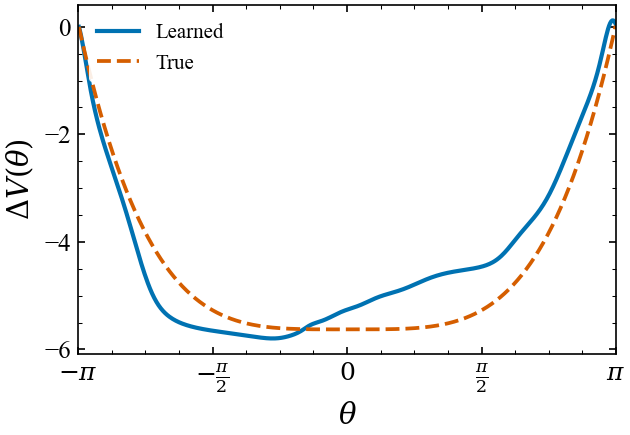

R2(dV) = 0.8393


In [65]:
# ── Delta-V net polynomial: ΔV on [-π, π] ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_gt, dvn_poly_dV_sorted, color=C_LEARNED, lw=2.0, label='Learned')
ax.plot(theta_gt, dvn_poly_true_dV, color=C_TRUE, lw=1.8, ls='--', label='True')

ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\Delta V(\theta)$')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(PI_TICKS)
ax.set_xticklabels(PI_LABELS)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_dvnet_poly.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_dvnet_poly.png'))
plt.show()
print(f'R2(dV) = {dvn_r2_poly:.4f}')

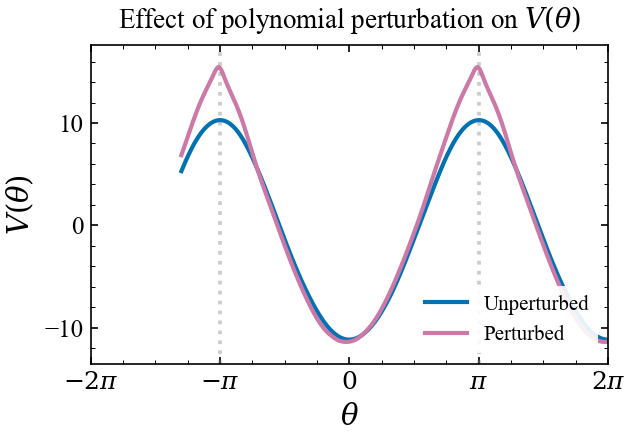

In [66]:
# ── Delta-V net polynomial: perturbed vs unperturbed V ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_ext_sorted, V_unpert_ext, color=C_LEARNED, lw=2.0, label='Unperturbed')
ax.plot(theta_ext_sorted, dvn_poly_Vtot_ext, color=C_PERT, lw=2.0, label='Perturbed')

ax.set_title(r'Effect of polynomial perturbation on $V(\theta)$', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$V(\theta)$')
ax.set_xlim(-2*np.pi, 2*np.pi)
ax.set_xticks(PI2_TICKS)
ax.set_xticklabels(PI2_LABELS)

y_min = min(V_unpert_ext.min(), dvn_poly_Vtot_ext.min())
y_max = max(V_unpert_ext.max(), dvn_poly_Vtot_ext.max())
y_pad = (y_max - y_min) * 0.08
ax.set_ylim(y_min - y_pad, y_max + y_pad)

ax.axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
ax.axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_dvnet_poly_perturbed.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_dvnet_poly_perturbed.png'))
plt.show()

### Delta-V Net — Sine Perturbation

In [67]:
# ── Delta-V net sine config ──
CKPT_DVN_SIN = '10sin6_372.ckpt'

DVN_A_SIN = 10.0
DVN_B_SIN = 6.372

dvn_true_da_sin  = lambda theta, M: DVN_A_SIN * np.sin(DVN_B_SIN * theta)
dvn_true_dV_sin  = lambda theta, M: M * (DVN_A_SIN / DVN_B_SIN) * np.cos(DVN_B_SIN * theta)

print(f'Delta-V net sine: A={DVN_A_SIN}, B={DVN_B_SIN}')
print(f'  Checkpoint: {CKPT_DVN_SIN}')

Delta-V net sine: A=10.0, B=6.372
  Checkpoint: 10sin6_372.ckpt


In [68]:
# ── Load delta-V net sine model ──
ckpt_path_dvn_sin = os.path.join(ckpt_dir, CKPT_DVN_SIN)
model_dvn_sin = DeltaVFrozenModel.load_from_checkpoint(ckpt_path_dvn_sin, map_location='cpu')
model_dvn_sin.eval()
print(f'Loaded DeltaVFrozenModel from {CKPT_DVN_SIN}')

dvn_sin_phys = extract_delta_v_physics(model_dvn_sin, theta_range)

dvn_sin_dV_sorted   = dvn_sin_phys['delta_V'][sort_idx]
dvn_sin_dV_sorted   = dvn_sin_dV_sorted - np.mean(dvn_sin_dV_sorted)
dvn_sin_dacc_sorted = dvn_sin_phys['delta_acc'][sort_idx]
dvn_sin_Vtot_sorted = dvn_sin_phys['V_total'][sort_idx]

# Ground truth
dvn_sin_true_dV_raw = dvn_true_dV_sin(theta_gt, M_scale)
dvn_sin_true_dV     = dvn_sin_true_dV_raw - np.mean(dvn_sin_true_dV_raw)

# Extended range
dvn_sin_ext = extract_delta_v_physics(model_dvn_sin, phi_ext)
dvn_sin_Vtot_ext = dvn_sin_ext['V_total'][sort_ext]

dvn_r2_sin = r2_score(dvn_sin_true_dV, dvn_sin_dV_sorted)
print(f'R2(dV sine, delta-V net) = {dvn_r2_sin:.4f}')
print('Delta-V net sine data ready.')

Loaded DeltaVFrozenModel from 10sin6_372.ckpt
R2(dV sine, delta-V net) = 0.0433
Delta-V net sine data ready.


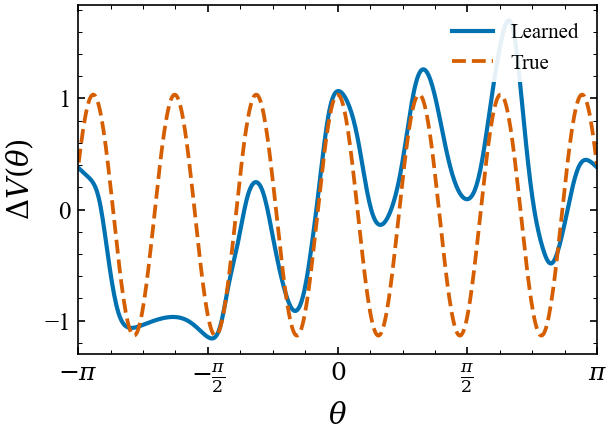

R2(dV) = 0.0433


In [69]:
# ── Delta-V net sine: ΔV on [-π, π] ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_gt, dvn_sin_dV_sorted, color=C_LEARNED, lw=2.0, label='Learned')
ax.plot(theta_gt, dvn_sin_true_dV, color=C_TRUE, lw=1.8, ls='--', label='True')

ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\Delta V(\theta)$')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(PI_TICKS)
ax.set_xticklabels(PI_LABELS)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_dvnet_sin.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_dvnet_sin.png'))
plt.show()
print(f'R2(dV) = {dvn_r2_sin:.4f}')

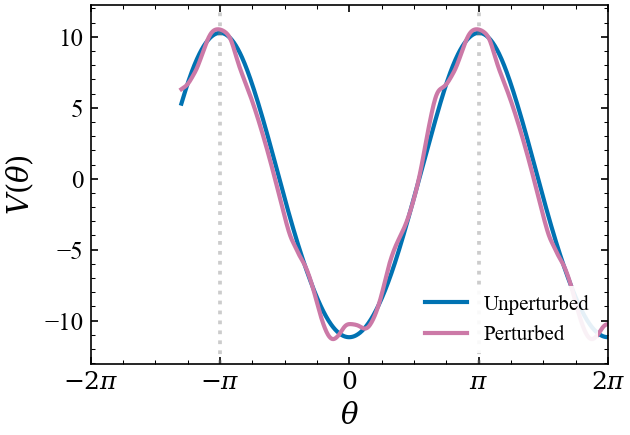

In [70]:
# ── Delta-V net sine: perturbed vs unperturbed V ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_ext_sorted, V_unpert_ext, color=C_LEARNED, lw=2.0, label='Unperturbed')
ax.plot(theta_ext_sorted, dvn_sin_Vtot_ext, color=C_PERT, lw=2.0, label='Perturbed')

ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$V(\theta)$')
ax.set_xlim(-2*np.pi, 2*np.pi)
ax.set_xticks(PI2_TICKS)
ax.set_xticklabels(PI2_LABELS)

y_min = min(V_unpert_ext.min(), dvn_sin_Vtot_ext.min())
y_max = max(V_unpert_ext.max(), dvn_sin_Vtot_ext.max())
y_pad = (y_max - y_min) * 0.08
ax.set_ylim(y_min - y_pad, y_max + y_pad)

ax.axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
ax.axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_dvnet_sin_perturbed.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_dvnet_sin_perturbed.png'))
plt.show()

---
# Sine Perturbation Plots

In [71]:
# ── Sine perturbation config ──
CKPT_DELTA_V_SIN = '10sin6_372_lora8.ckpt'

# Perturbation: da = A * sin(B * theta), dV = M * (A/B) * cos(B * theta)
A_SIN = 10.0
B_SIN = 6.372

true_da_sin     = lambda theta, M: A_SIN * np.sin(B_SIN * theta)
true_dV_raw_sin = lambda theta, M: M * (A_SIN / B_SIN) * np.cos(B_SIN * theta)

print(f'Sine perturbation: A={A_SIN}, B={B_SIN}')
print(f'  True da = {A_SIN} * sin({B_SIN} * theta)')
print(f'  True dV = M * {A_SIN}/{B_SIN} * cos({B_SIN} * theta)')

Sine perturbation: A=10.0, B=6.372
  True da = 10.0 * sin(6.372 * theta)
  True dV = M * 10.0/6.372 * cos(6.372 * theta)


In [72]:
# ── Load sine model & extract ──
ckpt_path_sin = os.path.join(ckpt_dir, CKPT_DELTA_V_SIN)
ckpt_data_sin = torch.load(ckpt_path_sin, map_location='cpu')
hp_sin = ckpt_data_sin.get('hyper_parameters', {})
is_lora_sin = 'lora_rank' in hp_sin
del ckpt_data_sin

if is_lora_sin:
    model_delta_v_sin = DeltaVLoRAModel.load_from_checkpoint(ckpt_path_sin, map_location='cpu')
    print(f"Loaded sine model as DeltaVLoRAModel (rank={hp_sin.get('lora_rank')})")
else:
    model_delta_v_sin = DeltaVFrozenModel.load_from_checkpoint(ckpt_path_sin, map_location='cpu')
    print("Loaded sine model as DeltaVFrozenModel")
model_delta_v_sin.eval()

if is_lora_sin:
    delta_v_sin_phys = extract_delta_v_physics_lora(model_delta_v_sin, theta_range)
else:
    delta_v_sin_phys = extract_delta_v_physics(model_delta_v_sin, theta_range)

# Sort to physical coordinates (reuse calib from polynomial section)
delta_V_sin_sorted   = delta_v_sin_phys['delta_V'][sort_idx]
delta_V_sin_sorted   = delta_V_sin_sorted - np.mean(delta_V_sin_sorted)
V_total_sin_sorted   = delta_v_sin_phys['V_total'][sort_idx]

# Ground truth for sine
true_dV_sin_raw = true_dV_raw_sin(theta_gt, M_scale)
true_dV_sin     = true_dV_sin_raw - np.mean(true_dV_sin_raw)

# Extended range
if is_lora_sin:
    dv_sin_ext = extract_delta_v_physics_lora(model_delta_v_sin, phi_ext)
else:
    dv_sin_ext = extract_delta_v_physics(model_delta_v_sin, phi_ext)
V_total_sin_ext = dv_sin_ext['V_total'][sort_ext]

r2_dV_sin = r2_score(true_dV_sin, delta_V_sin_sorted)
print(f'R2(dV sine) = {r2_dV_sin:.4f}')
print('Sine data ready.')

Loaded sine model as DeltaVLoRAModel (rank=8)
R2(dV sine) = 0.1815
Sine data ready.


## Figure 4 — Learned Sine Perturbation Potential $\Delta V$

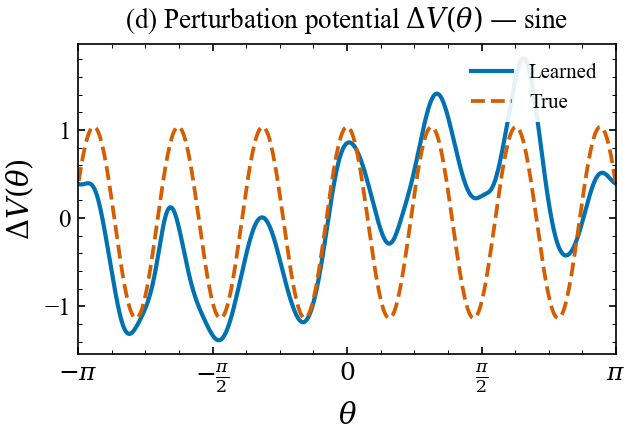

In [73]:
# ── Figure 4: Sine perturbation ΔV on [-π, π] ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_gt, delta_V_sin_sorted, color=C_LEARNED, lw=2.0, label='Learned')
ax.plot(theta_gt, true_dV_sin, color=C_TRUE, lw=1.8, ls='--', label='True')

ax.set_title(r'(d) Perturbation potential $\Delta V(\theta)$ — sine', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\Delta V(\theta)$')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(PI_TICKS)
ax.set_xticklabels(PI_LABELS)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_sine_learned.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_sine_learned.png'))
plt.show()

## Figure 5 — Effect of Sine Perturbation on $V(\theta)$

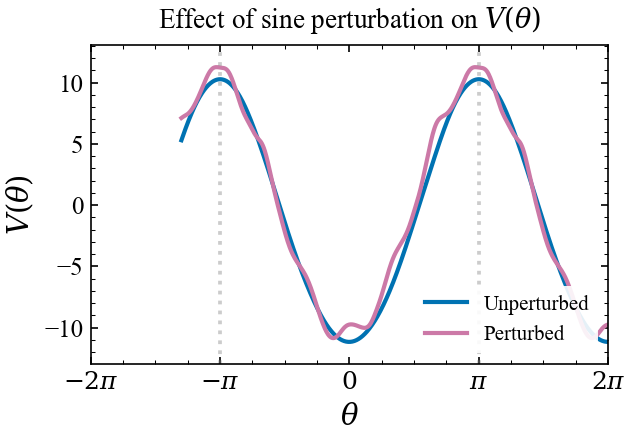

In [74]:
# ── Figure 5: Sine perturbed vs unperturbed potential ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_ext_sorted, V_unpert_ext, color=C_LEARNED, lw=2.0, label='Unperturbed')
ax.plot(theta_ext_sorted, V_total_sin_ext, color=C_PERT, lw=2.0, label='Perturbed')

ax.set_title(r'Effect of sine perturbation on $V(\theta)$', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$V(\theta)$')
ax.set_xlim(-2*np.pi, 2*np.pi)
ax.set_xticks(PI2_TICKS)
ax.set_xticklabels(PI2_LABELS)

# Set y-limits to cover full data range with padding
y_min = min(V_unpert_ext.min(), V_total_sin_ext.min())
y_max = max(V_unpert_ext.max(), V_total_sin_ext.max())
y_pad = (y_max - y_min) * 0.08
ax.set_ylim(y_min - y_pad, y_max + y_pad)

ax.axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
ax.axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_sine_perturbed.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_sine_perturbed.png'))
plt.show()

---
# LoRA Perturbation Plots

LoRA modifies V_net's internal weight matrices: $W_{\text{eff}} = W_{\text{frozen}} + \frac{\alpha}{r} A B$.
$\Delta V$ is extracted by comparing V_net output with vs without LoRA contribution.

In [75]:
# ── LoRA sine perturbation config ──
CKPT_LORA_SIN = '10sin6_372_lora8.ckpt'

# Same perturbation as delta-V sine section
A_LORA = 10.0
B_LORA = 6.372

true_da_lora     = lambda theta, M: A_LORA * np.sin(B_LORA * theta)
true_dV_raw_lora = lambda theta, M: M * (A_LORA / B_LORA) * np.cos(B_LORA * theta)

print(f'LoRA sine perturbation: A={A_LORA}, B={B_LORA}')
print(f'  True da = {A_LORA} * sin({B_LORA} * theta)')
print(f'  True dV = M * {A_LORA}/{B_LORA} * cos({B_LORA} * theta)')
print(f'  Checkpoint: {CKPT_LORA_SIN}')

LoRA sine perturbation: A=10.0, B=6.372
  True da = 10.0 * sin(6.372 * theta)
  True dV = M * 10.0/6.372 * cos(6.372 * theta)
  Checkpoint: 10sin6_372_lora8.ckpt


In [76]:
# ── Load LoRA model & extract ──
model_lora = DeltaVLoRAModel.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_LORA_SIN), map_location='cpu')
model_lora.eval()
print("LoRA model loaded.")

# Count LoRA params
lora_params = sum(p.numel() for n, p in model_lora.named_parameters() if 'lora_' in n)
print(f"  LoRA parameters: {lora_params}")

# Extract physics using LoRA-specific helper
dv_lora_phys = extract_delta_v_physics_lora(model_lora, theta_range)

# Sort to physical coordinates (reuse calib from polynomial section)
delta_V_lora_sorted   = dv_lora_phys['delta_V'][sort_idx]
delta_V_lora_sorted   = delta_V_lora_sorted - np.mean(delta_V_lora_sorted)
V_total_lora_sorted   = dv_lora_phys['V_total'][sort_idx]
delta_acc_lora_sorted = dv_lora_phys['delta_acc'][sort_idx]

# Ground truth
true_dV_lora_raw = true_dV_raw_lora(theta_gt, M_scale)
true_dV_lora     = true_dV_lora_raw - np.mean(true_dV_lora_raw)
true_da_lora_vals = true_da_lora(theta_gt, M_scale)

# Extended range
dv_lora_ext = extract_delta_v_physics_lora(model_lora, phi_ext)
V_total_lora_ext = dv_lora_ext['V_total'][sort_ext]

# R2 scores
r2_dV_lora = r2_score(true_dV_lora, delta_V_lora_sorted)
r2_da_lora = r2_score(true_da_lora_vals, delta_acc_lora_sorted)

print(f'R2(dV LoRA) = {r2_dV_lora:.4f}')
print(f'R2(da LoRA) = {r2_da_lora:.4f}')
print('LoRA data ready.')

LoRA model loaded.
  LoRA parameters: 1624
R2(dV LoRA) = 0.1815
R2(da LoRA) = 0.7347
LoRA data ready.


## Figure 6 — LoRA Learned Perturbation Potential $\Delta V$

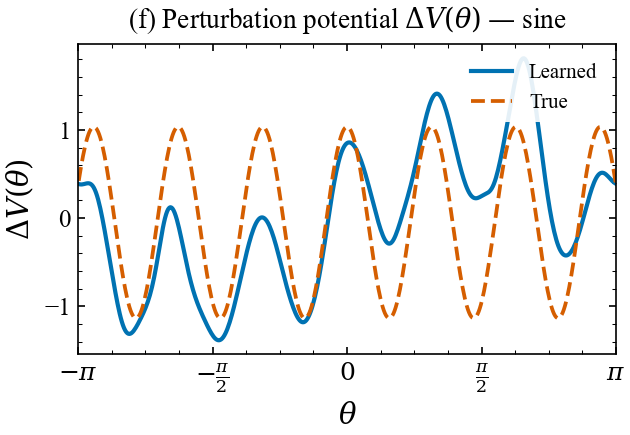

R2(dV) = 0.1815


In [77]:
# ── Figure 6: LoRA perturbation ΔV on [-π, π] ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_gt, delta_V_lora_sorted, color=C_LEARNED, lw=2.0, label='Learned')
ax.plot(theta_gt, true_dV_lora, color=C_TRUE, lw=1.8, ls='--', label='True')

ax.set_title(r'(f) Perturbation potential $\Delta V(\theta)$ — sine', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\Delta V(\theta)$')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(PI_TICKS)
ax.set_xticklabels(PI_LABELS)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_lora_learned.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_lora_learned.png'))
plt.show()
print(f'R2(dV) = {r2_dV_lora:.4f}')

## Figure 7 — Effect of LoRA Perturbation on $V(\theta)$

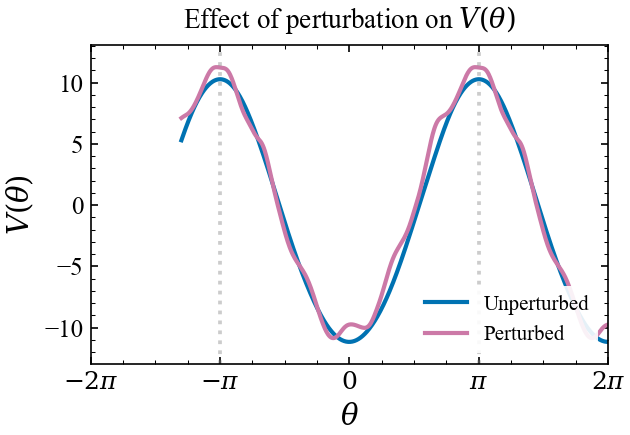

In [78]:
# ── Figure 7: Perturbed vs unperturbed potential ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_ext_sorted, V_unpert_ext, color=C_LEARNED, lw=2.0, label='Unperturbed')
ax.plot(theta_ext_sorted, V_total_lora_ext, color=C_PERT, lw=2.0, label='Perturbed')

ax.set_title(r'Effect of perturbation on $V(\theta)$', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$V(\theta)$')
ax.set_xlim(-2*np.pi, 2*np.pi)
ax.set_xticks(PI2_TICKS)
ax.set_xticklabels(PI2_LABELS)

y_min = min(V_unpert_ext.min(), V_total_lora_ext.min())
y_max = max(V_unpert_ext.max(), V_total_lora_ext.max())
y_pad = (y_max - y_min) * 0.08
ax.set_ylim(y_min - y_pad, y_max + y_pad)

ax.axvline(x=-np.pi, color='gray', ls=':', alpha=0.4)
ax.axvline(x=np.pi, color='gray', ls=':', alpha=0.4)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_lora_perturbed.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_V_lora_perturbed.png'))
plt.show()

## Figure 8 — Comparison: Delta-V net vs LoRA

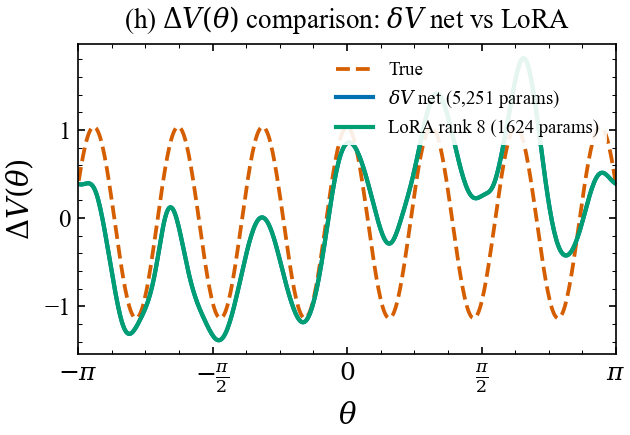

R2(dV) delta-V net: 0.1815
R2(dV) LoRA:        0.1815


In [79]:
# ── Figure 8: Side-by-side comparison of delta-V net vs LoRA ──
# Only runs if both sine delta-V and LoRA models are loaded

C_LORA = '#009E73'  # teal/green (colorblind safe)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(theta_gt, true_dV_sin, color=C_TRUE, lw=1.8, ls='--', label='True')
ax.plot(theta_gt, delta_V_sin_sorted, color=C_LEARNED, lw=2.0, label=r'$\delta V$ net (5,251 params)')
ax.plot(theta_gt, delta_V_lora_sorted, color=C_LORA, lw=2.0, label=f'LoRA rank 8 ({lora_params} params)')

ax.set_title(r'(h) $\Delta V(\theta)$ comparison: $\delta V$ net vs LoRA', fontsize=13, pad=8)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\Delta V(\theta)$')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(PI_TICKS)
ax.set_xticklabels(PI_LABELS)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor='none')
ax.minorticks_on()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_comparison.pdf'))
fig.savefig(os.path.join(SAVE_DIR, 'fig_deltaV_comparison.png'))
plt.show()

print(f'R2(dV) delta-V net: {r2_dV_sin:.4f}')
print(f'R2(dV) LoRA:        {r2_dV_lora:.4f}')

---
# Export Plot Data to CSV

Export all plot data so figures can be reproduced independently.

In [80]:
# ── Export all plot data to CSV files ──
import pandas as pd

CSV_DIR = os.path.join(SAVE_DIR, 'csv_data')
os.makedirs(CSV_DIR, exist_ok=True)

# --- Figure 1: Unperturbed potential V(θ) on [-2π, 2π] ---
pd.DataFrame({
    'theta': theta_ext_sorted,
    'V_unperturbed': V_unpert_ext,
}).to_csv(os.path.join(CSV_DIR, 'fig1_V_unperturbed.csv'), index=False)

# --- Figure 2: LoRA polynomial ΔV on [-π, π] ---
pd.DataFrame({
    'theta': theta_gt,
    'delta_V_learned': delta_V_sorted,
    'delta_V_true': true_delta_V,
}).to_csv(os.path.join(CSV_DIR, 'fig2_deltaV_lora_poly.csv'), index=False)

# --- Figure 3: LoRA polynomial perturbed vs unperturbed V on [-2π, 2π] ---
pd.DataFrame({
    'theta': theta_ext_sorted,
    'V_unperturbed': V_unpert_ext,
    'V_perturbed_lora_poly': V_total_ext,
}).to_csv(os.path.join(CSV_DIR, 'fig3_V_lora_poly_perturbed.csv'), index=False)

# --- Delta-V net polynomial ΔV ---
try:
    pd.DataFrame({
        'theta': theta_gt,
        'delta_V_learned': dvn_poly_dV_sorted,
        'delta_V_true': dvn_poly_true_dV,
    }).to_csv(os.path.join(CSV_DIR, 'deltaV_dvnet_poly.csv'), index=False)
    
    pd.DataFrame({
        'theta': theta_ext_sorted,
        'V_unperturbed': V_unpert_ext,
        'V_perturbed_dvnet_poly': dvn_poly_Vtot_ext,
    }).to_csv(os.path.join(CSV_DIR, 'V_dvnet_poly_perturbed.csv'), index=False)
    print('Exported delta-V net polynomial CSVs')
except NameError:
    print('Skipping delta-V net polynomial (not loaded)')

# --- Delta-V net sine ΔV ---
try:
    pd.DataFrame({
        'theta': theta_gt,
        'delta_V_learned': dvn_sin_dV_sorted,
        'delta_V_true': dvn_sin_true_dV,
    }).to_csv(os.path.join(CSV_DIR, 'deltaV_dvnet_sin.csv'), index=False)
    
    pd.DataFrame({
        'theta': theta_ext_sorted,
        'V_unperturbed': V_unpert_ext,
        'V_perturbed_dvnet_sin': dvn_sin_Vtot_ext,
    }).to_csv(os.path.join(CSV_DIR, 'V_dvnet_sin_perturbed.csv'), index=False)
    print('Exported delta-V net sine CSVs')
except NameError:
    print('Skipping delta-V net sine (not loaded)')

# --- LoRA sine ΔV ---
try:
    pd.DataFrame({
        'theta': theta_gt,
        'delta_V_learned': delta_V_sin_sorted,
        'delta_V_true': true_dV_sin,
    }).to_csv(os.path.join(CSV_DIR, 'deltaV_lora_sin.csv'), index=False)
    
    pd.DataFrame({
        'theta': theta_ext_sorted,
        'V_unperturbed': V_unpert_ext,
        'V_perturbed_lora_sin': V_total_sin_ext,
    }).to_csv(os.path.join(CSV_DIR, 'V_lora_sin_perturbed.csv'), index=False)
    print('Exported LoRA sine CSVs')
except NameError:
    print('Skipping LoRA sine (not loaded)')

# --- LoRA separate section ΔV ---
try:
    pd.DataFrame({
        'theta': theta_gt,
        'delta_V_learned': delta_V_lora_sorted,
        'delta_V_true': true_dV_lora,
    }).to_csv(os.path.join(CSV_DIR, 'deltaV_lora_section.csv'), index=False)
    
    pd.DataFrame({
        'theta': theta_ext_sorted,
        'V_unperturbed': V_unpert_ext,
        'V_perturbed_lora_section': V_total_lora_ext,
    }).to_csv(os.path.join(CSV_DIR, 'V_lora_section_perturbed.csv'), index=False)
    print('Exported LoRA section CSVs')
except NameError:
    print('Skipping LoRA section (not loaded)')

# --- Comparison (delta-V net vs LoRA) ---
try:
    pd.DataFrame({
        'theta': theta_gt,
        'delta_V_true': true_dV_sin,
        'delta_V_dvnet': delta_V_sin_sorted,
        'delta_V_lora': delta_V_lora_sorted,
    }).to_csv(os.path.join(CSV_DIR, 'deltaV_comparison.csv'), index=False)
    print('Exported comparison CSV')
except NameError:
    print('Skipping comparison (not all models loaded)')

print(f'\nAll CSVs saved to: {CSV_DIR}')
print('Files:')
for f in sorted(os.listdir(CSV_DIR)):
    if f.endswith('.csv'):
        print(f'  {f}')

Exported delta-V net polynomial CSVs
Exported delta-V net sine CSVs
Exported LoRA sine CSVs
Exported LoRA section CSVs
Exported comparison CSV

All CSVs saved to: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/results/pend/paper_figures/csv_data
Files:
  V_dvnet_poly_perturbed.csv
  V_dvnet_sin_perturbed.csv
  V_lora_section_perturbed.csv
  V_lora_sin_perturbed.csv
  deltaV_comparison.csv
  deltaV_dvnet_poly.csv
  deltaV_dvnet_sin.csv
  deltaV_lora_section.csv
  deltaV_lora_sin.csv
  fig1_V_unperturbed.csv
  fig2_deltaV_lora_poly.csv
  fig3_V_lora_poly_perturbed.csv
